In [56]:
from itertools import count

import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

from matplotlib.pyplot import subplots_adjust

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
sorted(Path(root_output_directory).iterdir(), key=os.path.getmtime)
# root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon"
# scenario_name = "old_params_extensive"
root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "big_overview_20_10000p"

#scenario_name = "r2000_a20"
input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')
vars_total = ['psi_leaf_50_close', 'd_50_close', 'stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value','psi88_xylem',
              'leaf_hydraulic_capacitance', 'psi50_xylem', 'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0',
              'jackson_root_beta', 'pore_0', 'anet_max', 'root_area_index', 'wcont_sigma_deviation', 'g_bark']

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem','psi88_xylem',
              'g0', 'jackson_root_beta']

df = pd.read_csv(os.path.join(post_path, "aggregated_out.csv"))
df.sort_values(by=['RMSE_MAX'], inplace=True, ascending=True)
df = df[df['RMSE_MAX'] < 1.1]
index_to_drop = df[(df['sid'] == 2) | (df['sid'] == 2)].index
df.drop(index_to_drop, inplace=True)
df_mean = df.groupby(['id'])[vars_total].mean()

In [57]:
df_norm = (df_mean - df_mean.mean()) / df_mean.std()

In [58]:
df_norm[vars_plant]

,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,psi88_xylem,g0,jackson_root_beta
id,,,,,,,,
0,-0.024833,-0.710175,-1.008777,3.096372,-0.042792,-0.065704,-0.316975,0.699678
1,0.487747,-1.390489,-1.803056,0.640739,-0.557488,-0.502196,-0.899387,-1.432795
4,-0.013925,0.701827,-1.282857,-0.298265,1.642805,1.050898,-0.771434,-0.829377
10,1.110928,-0.257505,0.042891,-1.003445,-0.382535,-0.554770,1.031241,0.924208
12,-1.225475,-0.267036,1.178134,-0.792859,1.119059,1.051759,-0.117559,0.948554
...,...,...,...,...,...,...,...,...
2443,0.528714,-0.597999,-0.107819,-0.634085,-0.435185,-0.615999,0.051203,0.849268
2447,-0.040935,1.659323,0.104880,1.700610,-1.233830,-1.088301,-0.321819,-0.101103
2452,0.922532,2.122231,0.838481,-0.958762,0.035866,0.175725,1.788496,-1.366495


In [59]:
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.metrics import silhouette_score

In [101]:
vars_sel = ['stem_hydraulic_capacitance', 'k_xylem_sat','huber_value', 'psi50_xylem','g0']
vars_sel_name = [  r"$\Gamma_\mathrm{Stem}$",r"$k_\mathrm{xyl}$",r"Huber", r'$\Psi_{50}$', r"$g_0$"]
units = ["mol m-3 MPa-1", "mol m-1 s-1 MPa-1", "-", "MPa", "mol m-1 s-1"]


In [91]:
kmeans = KMeans(n_clusters = 3, random_state = 0, n_init='auto')
kmeans.fit(df_norm[vars_plant])

KMeans(n_clusters=3, random_state=0)

In [92]:
K = range(2, 12)
fits = []

scorss = []
for s in range(100):
    score = []
    for k in K:
        # train the model for current value of k on training data
        model = KMeans(n_clusters = k, random_state = s, n_init='auto').fit(df_norm[vars_sel])

        # append the model to fits
        fits.append(model)

        # Append the silhouette score to scores
        score.append(silhouette_score(df_norm[vars_sel], model.labels_, metric='euclidean'))
    scorss.append(score)


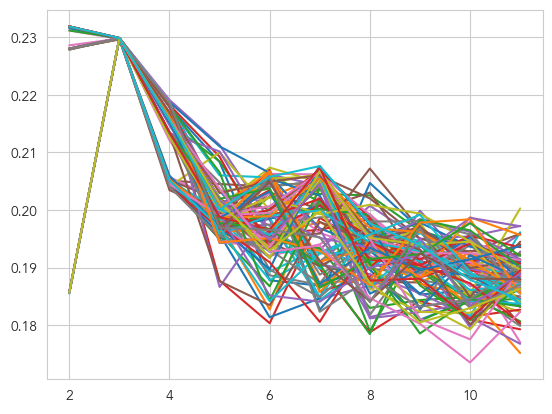

In [81]:
plt.plot(K, np.array(scorss).T);

In [89]:
kmeans = KMeans(n_clusters = 3, random_state = 9
                , n_init='auto')
kmeans.fit(df_norm[vars_sel])
np.round(silhouette_score(df_norm[vars_sel], kmeans.labels_, metric='euclidean'),3)


0.23

In [98]:
unique, counts = np.unique(kmeans.labels_, return_counts=True)
counts
countslabs = [f'G{i+1} ({counts[i]})'for i in range(3)]


/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_13630/3091743761.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(countslabs)
/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_13630/3091743761.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(countslabs)
/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_13630/3091743761.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(countslabs)
/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_13630/3091743761.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(countslabs)
/var/folders/9r/97b9zk_j4ys8

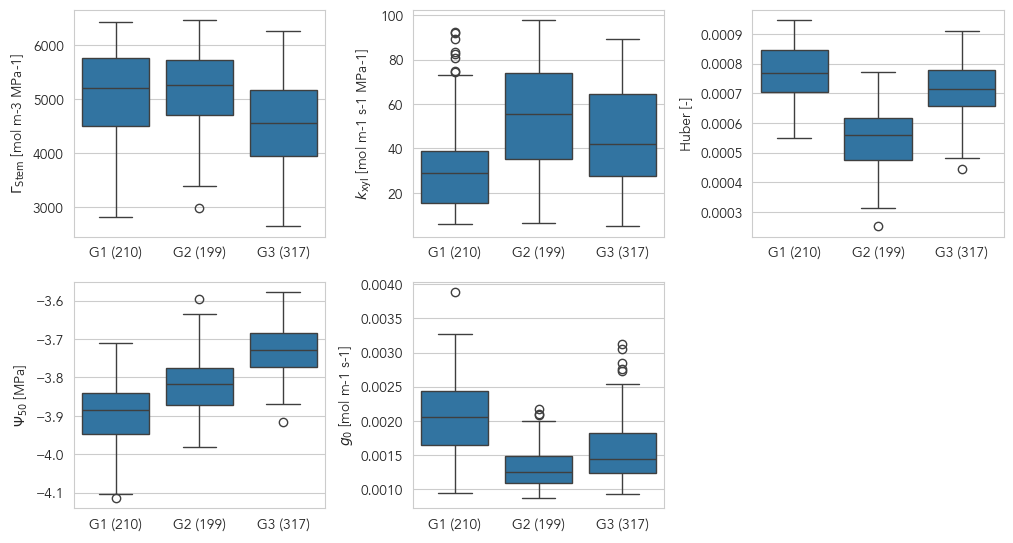

In [103]:
plt.rcParams["font.family"] = "Avenir"
fig = plt.figure(figsize = (12,10))
for index,  var in zip(np.arange(1, len(vars_sel)+1), vars_sel):
    ax = fig.add_subplot(3,3, index)
    ax.set_xticklabels(countslabs)
    ax.set_ylabel(f"{vars_sel_name[index-1]} [{units[index-1]}]")
    sns.boxplot(x = kmeans.labels_, y = df_mean[var], ax=ax)
plt.subplots_adjust(wspace=0.35)
plt.savefig(f"{post_path}/figure4_kmeans_cluster.png", bbox_inches='tight', dpi = 300)


In [36]:
from sklearn.cluster import MeanShift
from sklearn import metrics

db = MeanShift(bandwidth=2).fit(df_norm[vars_plant])

labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)
print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)
print(df"Silhouette Coefficient: {metrics.silhouette_score(df_norm[vars_plant], db.labels_,metric='euclidean'):.3f}")

Estimated number of clusters: 8
Estimated number of noise points: 0
Silhouette Coefficient: 0.013


In [24]:
df_norm[vars_plant]

,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,g0,jackson_root_beta
id,,,,,,,
0,-0.024833,-0.710175,-1.008777,3.096372,-0.042792,-0.316975,0.699678
1,0.487747,-1.390489,-1.803056,0.640739,-0.557488,-0.899387,-1.432795
4,-0.013925,0.701827,-1.282857,-0.298265,1.642805,-0.771434,-0.829377
10,1.110928,-0.257505,0.042891,-1.003445,-0.382535,1.031241,0.924208
12,-1.225475,-0.267036,1.178134,-0.792859,1.119059,-0.117559,0.948554
...,...,...,...,...,...,...,...
2443,0.528714,-0.597999,-0.107819,-0.634085,-0.435185,0.051203,0.849268
2447,-0.040935,1.659323,0.104880,1.700610,-1.233830,-0.321819,-0.101103
2452,0.922532,2.122231,0.838481,-0.958762,0.035866,1.788496,-1.366495


array([5, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0,
       7, 0, 0, 6, 0, 0, 0, 0, 0, 0, 0, 0, 3, 1, 3, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 6, 0, 0, 0, 7, 0, 0, 0, 0, 0, 3, 7, 0, 2, 0, 0,
       0, 0, 0, 0, 5, 0, 0, 7, 0, 0, 0, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 7, 0, 0, 3, 0,
       1, 0, 0, 2, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 6, 0, 0, 0, 0,
       0, 0, 0, 3, 0, 0, 0, 0, 0, 4, 4, 0, 0, 0, 0, 3, 6, 3, 6, 3, 0, 0,
       0, 0, 0, 1, 0, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0,
       5, 0, 0, 0, 0, 0, 0, 0, 6, 7, 0, 0, 7, 0, 0, 0, 0, 0, 0, 1, 6, 0,
       7, 0, 0, 0, 0, 7, 0, 0, 0, 7, 0, 0, 0, 0, 0, 6, 3, 0, 0, 0, 0, 0,
       0, 0, 5, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 4, 6, 0, 0, 3, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
unique, counts = numpy.unique(a, return_counts=True)

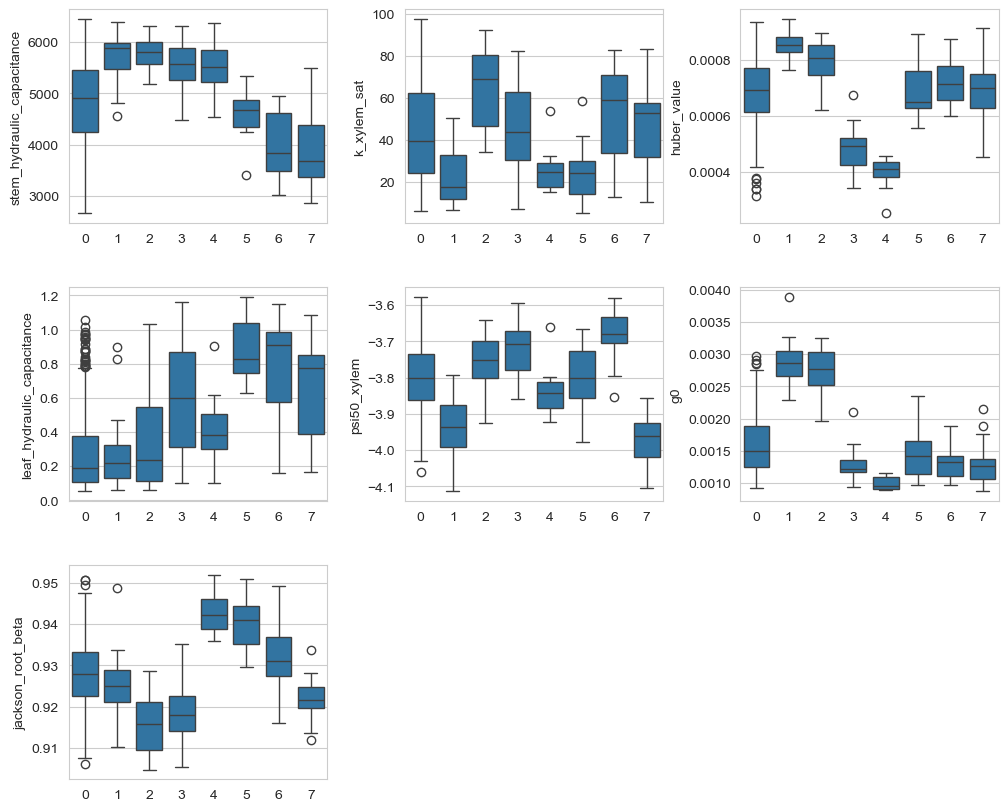

In [40]:
fig = plt.figure(figsize = (12,10))
for index,  var in zip(np.arange(1, len(vars_plant)+1), vars_plant):
    ax = fig.add_subplot(3,3, index)
    sns.boxplot(x = labels, y = df_mean[var], ax=ax)
fig.subplots_adjust(wspace=0.3, hspace=0.3)

<Axes: >

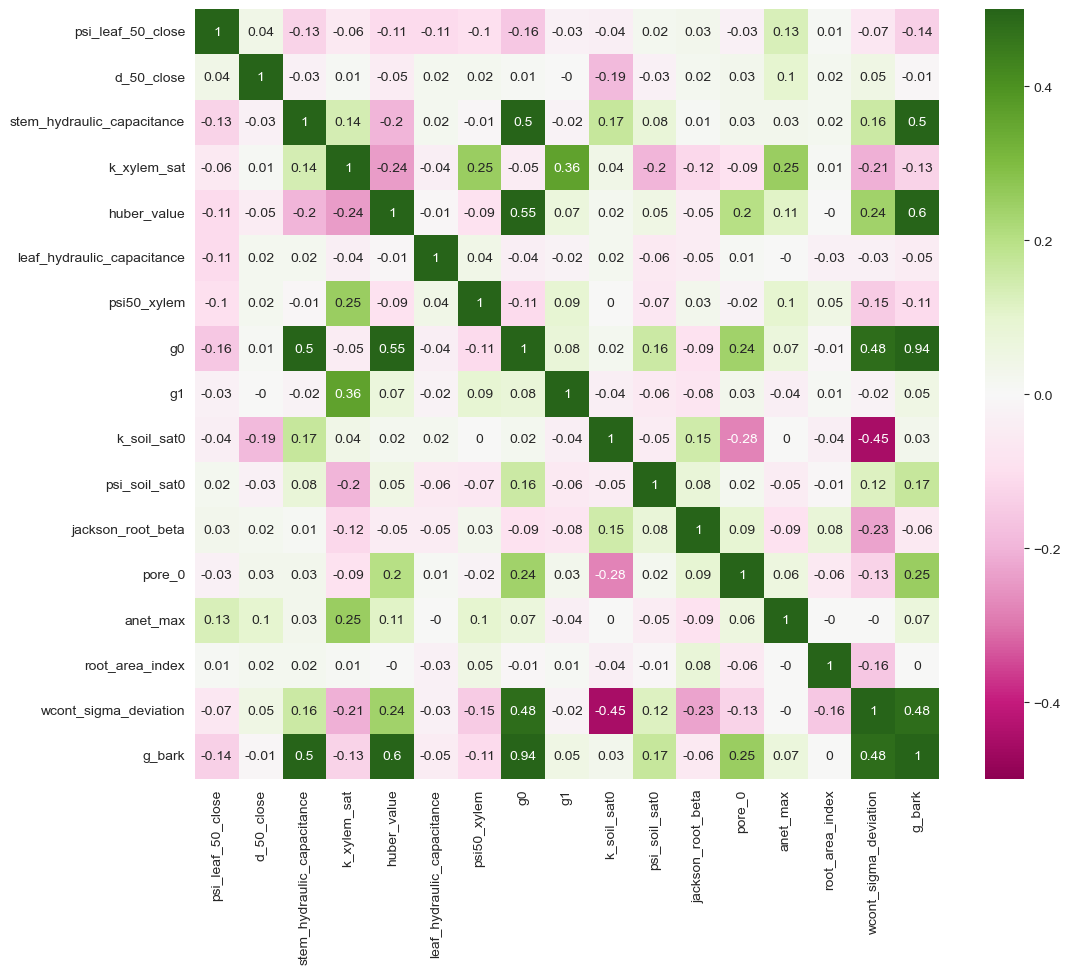

In [39]:
corr_matrix = df_mean.corr(method='spearman').round(2)
#corr_matrix.style.background_gradient(cmap='Greens')
plt.figure(figsize = (12,10))
sns.heatmap(corr_matrix, annot=True, vmin=-0.5, vmax=0.5, cmap="PiYG")